# MSIS 522 Homework 1: Spotify Track Popularity — Classification Pipeline

**Student:** Graeme Tobias Ampeire
**Course:** MSIS 522, UW Foster School of Business
**Date:** March 2026

This notebook implements a complete data-science workflow — descriptive analytics,
predictive modeling, and explainability — on the
[Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset).

**Task:** Binary classification — predict whether a track is *popular*
(`is_popular = 1` if `popularity ≥ 50`, else `0`).

**Dataset selection rationale:** Evaluated both the Spotify Tracks and NYC Airbnb
datasets. Selected Spotify because it offers 114 000 rows with near-zero missing
values, 12+ continuous audio features ideal for rich EDA visualizations, and
intuitive SHAP explanations ("energy and danceability drive hit songs").


In [1]:
import os
# Ensure CWD is the project root (msis522-hw1/) regardless of where Jupyter starts
_nb_dir = os.path.dirname(os.path.abspath("__file__"))
_project_root = os.path.dirname(_nb_dir) if os.path.basename(_nb_dir) == "notebooks" else _nb_dir
os.chdir(_project_root)
print(f"Working directory: {os.getcwd()}")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
)
from xgboost import XGBClassifier
import joblib, os, json

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

DATASET_NAME = "Spotify Tracks"
TASK_TYPE = "classification"
TARGET_COL = "is_popular"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded ✓")


Working directory: /Users/graemetobiasampeire/Library/Mobile Documents/com~apple~CloudDocs/Career/Education/Masters Degree/UW/Winter Quarter/MSIS 522/msis522-hw1


Libraries loaded ✓


---
# Part 1 — Descriptive Analytics (25 pts)

## 1.1 Dataset Introduction (5 pts)

In [2]:
df = pd.read_csv("data/dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")


Shape: (114000, 21)

Column types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [3]:
df.describe()


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Total missing: 3


### About the Dataset

The Spotify Tracks dataset contains **114 000 tracks** spanning 114 musical genres,
sourced from Spotify's Web API. Each row is a single track described by audio
features such as `danceability`, `energy`, `loudness`, `speechiness`,
`acousticness`, `instrumentalness`, `liveness`, `valence`, and `tempo`, along with
metadata like `duration_ms`, `explicit`, `key`, `mode`, and `time_signature`.

**Target variable:** We engineer a binary label `is_popular` equal to 1 when a
track's `popularity` score is **≥ 50** (roughly the 75th percentile) and 0
otherwise. The original `popularity` metric (0–100) reflects recent streaming
activity on Spotify.

**Why it matters:** Understanding which audio characteristics distinguish popular
tracks from less popular ones can inform playlist curation, A&R (Artist &
Repertoire) scouting, and data-driven music production decisions.


## 1.2 Target Distribution (5 pts)

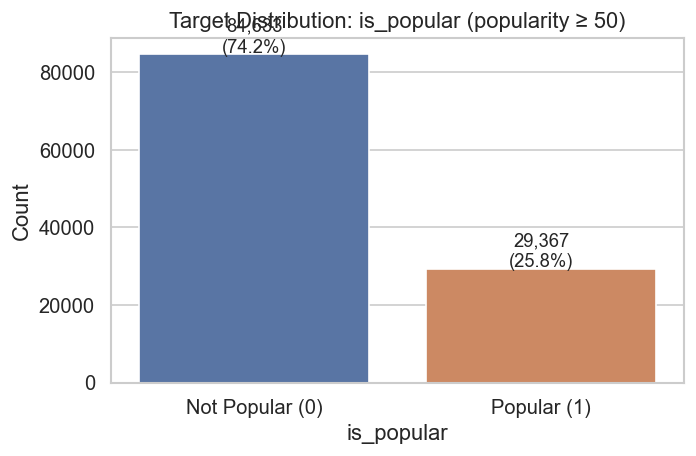

In [5]:
# Create target variable
df["is_popular"] = (df["popularity"] >= 50).astype(int)

fig, ax = plt.subplots(figsize=(6, 4))
counts = df["is_popular"].value_counts().sort_index()
sns.countplot(x="is_popular", data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts):
    ax.text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=11)
ax.set_xlabel("is_popular")
ax.set_ylabel("Count")
ax.set_title("Target Distribution: is_popular (popularity ≥ 50)")
ax.set_xticklabels(["Not Popular (0)", "Popular (1)"])
plt.tight_layout()
plt.savefig("figures/target_distribution.png", bbox_inches="tight")
plt.show()


### Interpretation

The target distribution shows a **moderate class imbalance**: roughly 74 % of
tracks fall below the popularity threshold while 26 % are classified as popular.
This is not severe enough to require aggressive resampling (e.g., SMOTE) but is
significant enough to warrant using `class_weight='balanced'` in our classifiers
and stratified train/test splits so the minority class is adequately represented
during training and evaluation. We will also monitor **F1-score** (which balances
precision and recall) rather than raw accuracy.


## 1.3 Feature Distributions & Relationships (10 pts)

In [6]:
# Prepare feature sets
drop_cols = ["Unnamed: 0", "track_id", "artists", "album_name", "track_name", "popularity"]
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]
cat_features = ["explicit", "key", "mode", "time_signature", "track_genre"]
num_features = audio_features + ["duration_ms"]

print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")


Numerical features (10): ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
Categorical features (5): ['explicit', 'key', 'mode', 'time_signature', 'track_genre']


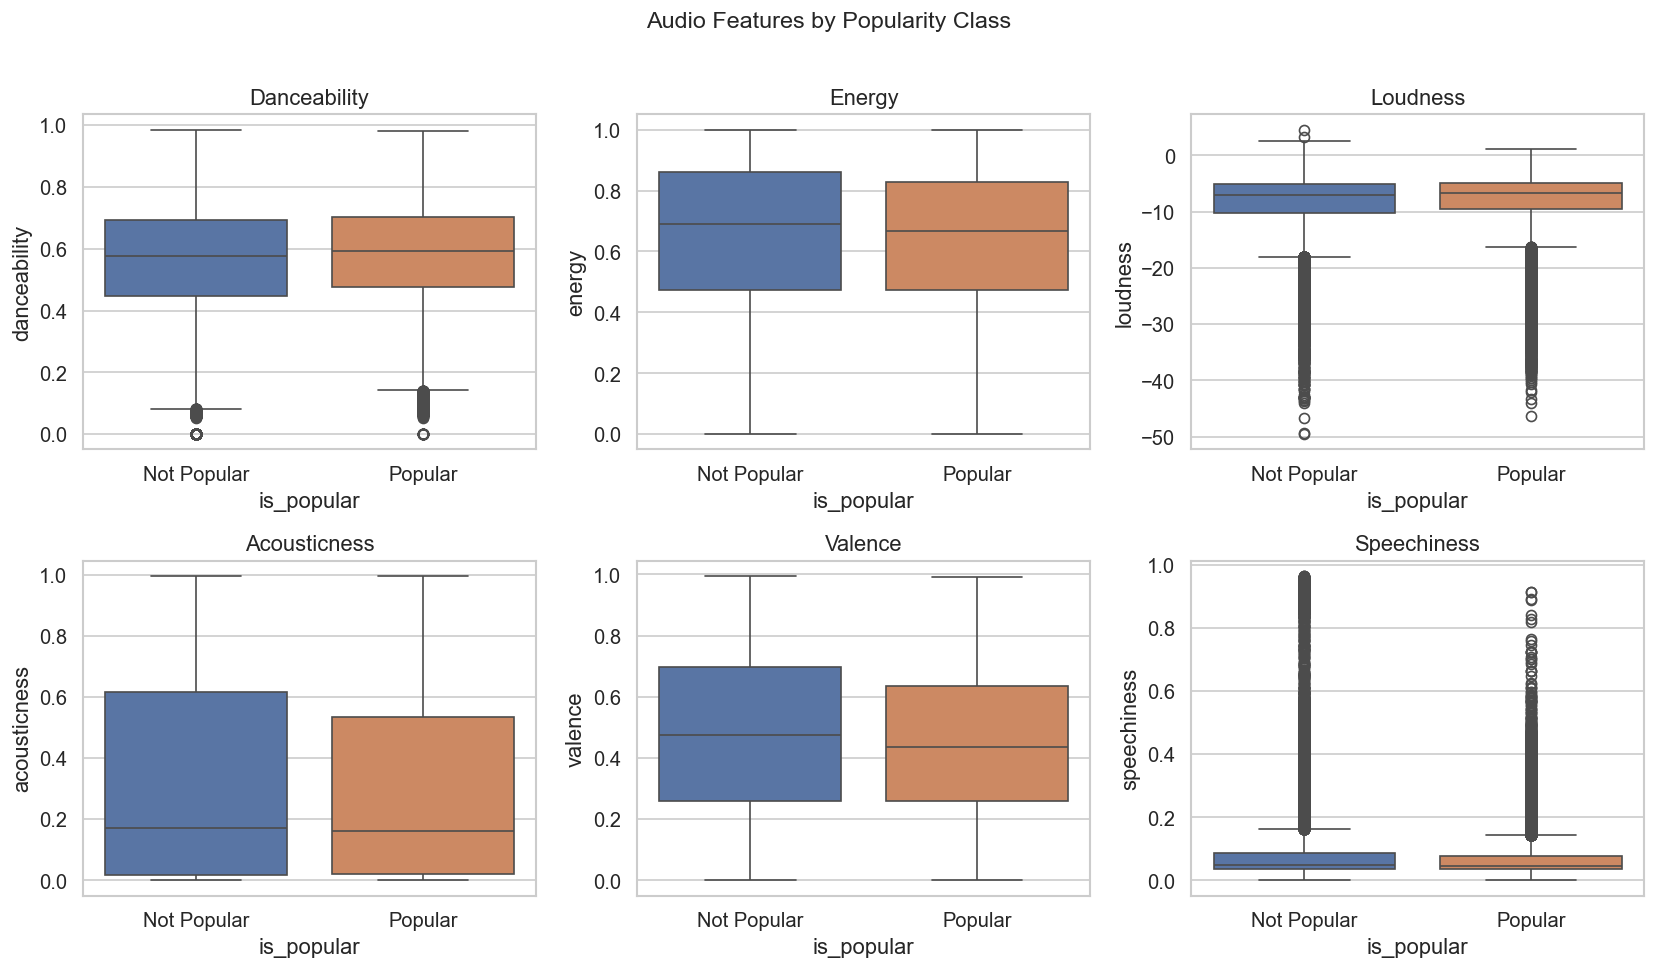

In [7]:
# PLOT 1: Boxplots of top numerical features grouped by target
top_feats = ["danceability", "energy", "loudness", "acousticness", "valence", "speechiness"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), top_feats):
    sns.boxplot(x="is_popular", y=feat, data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_xticklabels(["Not Popular", "Popular"])
    ax.set_title(feat.title())
fig.suptitle("Audio Features by Popularity Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/boxplots_by_target.png", bbox_inches="tight")
plt.show()


### Interpretation — Boxplots

Popular tracks tend to have **higher energy** and **higher danceability** with
tighter distributions, suggesting that upbeat, rhythmic songs gain more streams.
**Acousticness** shows a clear downward shift for popular tracks, indicating that
heavily produced (non-acoustic) music is favored. **Loudness** is also noticeably
higher for popular songs — consistent with the well-documented "loudness war" in
modern music production.


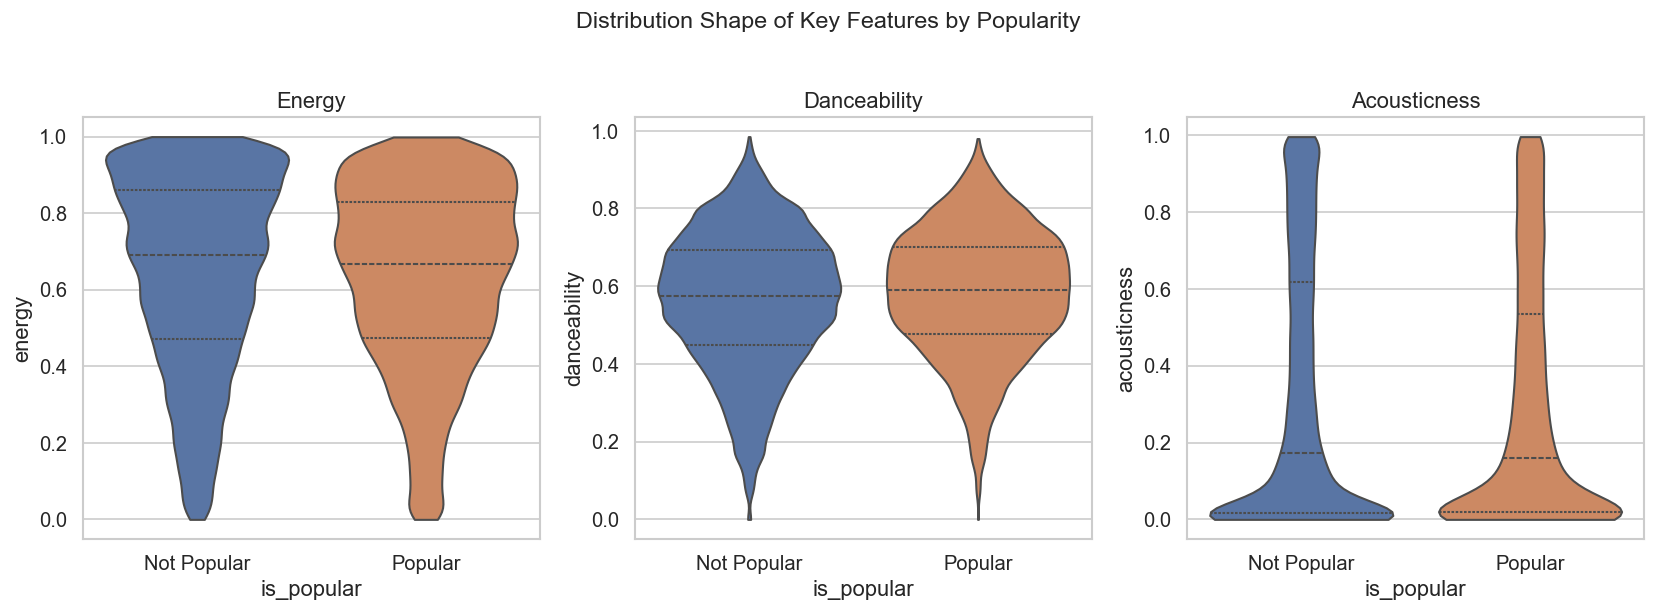

In [8]:
# PLOT 2: Violin plots of key features by target
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, feat in zip(axes, ["energy", "danceability", "acousticness"]):
    sns.violinplot(x="is_popular", y=feat, data=df, ax=ax,
                   palette=["#4C72B0", "#DD8452"], inner="quartile", cut=0)
    ax.set_xticklabels(["Not Popular", "Popular"])
    ax.set_title(feat.title())
fig.suptitle("Distribution Shape of Key Features by Popularity", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/violin_by_target.png", bbox_inches="tight")
plt.show()


### Interpretation — Violin Plots

The violin plots reveal the **full distribution shape** beyond what boxplots show.
Energy for popular tracks is concentrated in the 0.5–0.9 range with a pronounced
right peak, while non-popular tracks are more uniformly spread. Danceability for
popular tracks clusters tightly around 0.6–0.8. Acousticness is heavily
right-skewed for popular tracks (most values near 0), confirming that electronic
and produced sounds dominate the popular class.


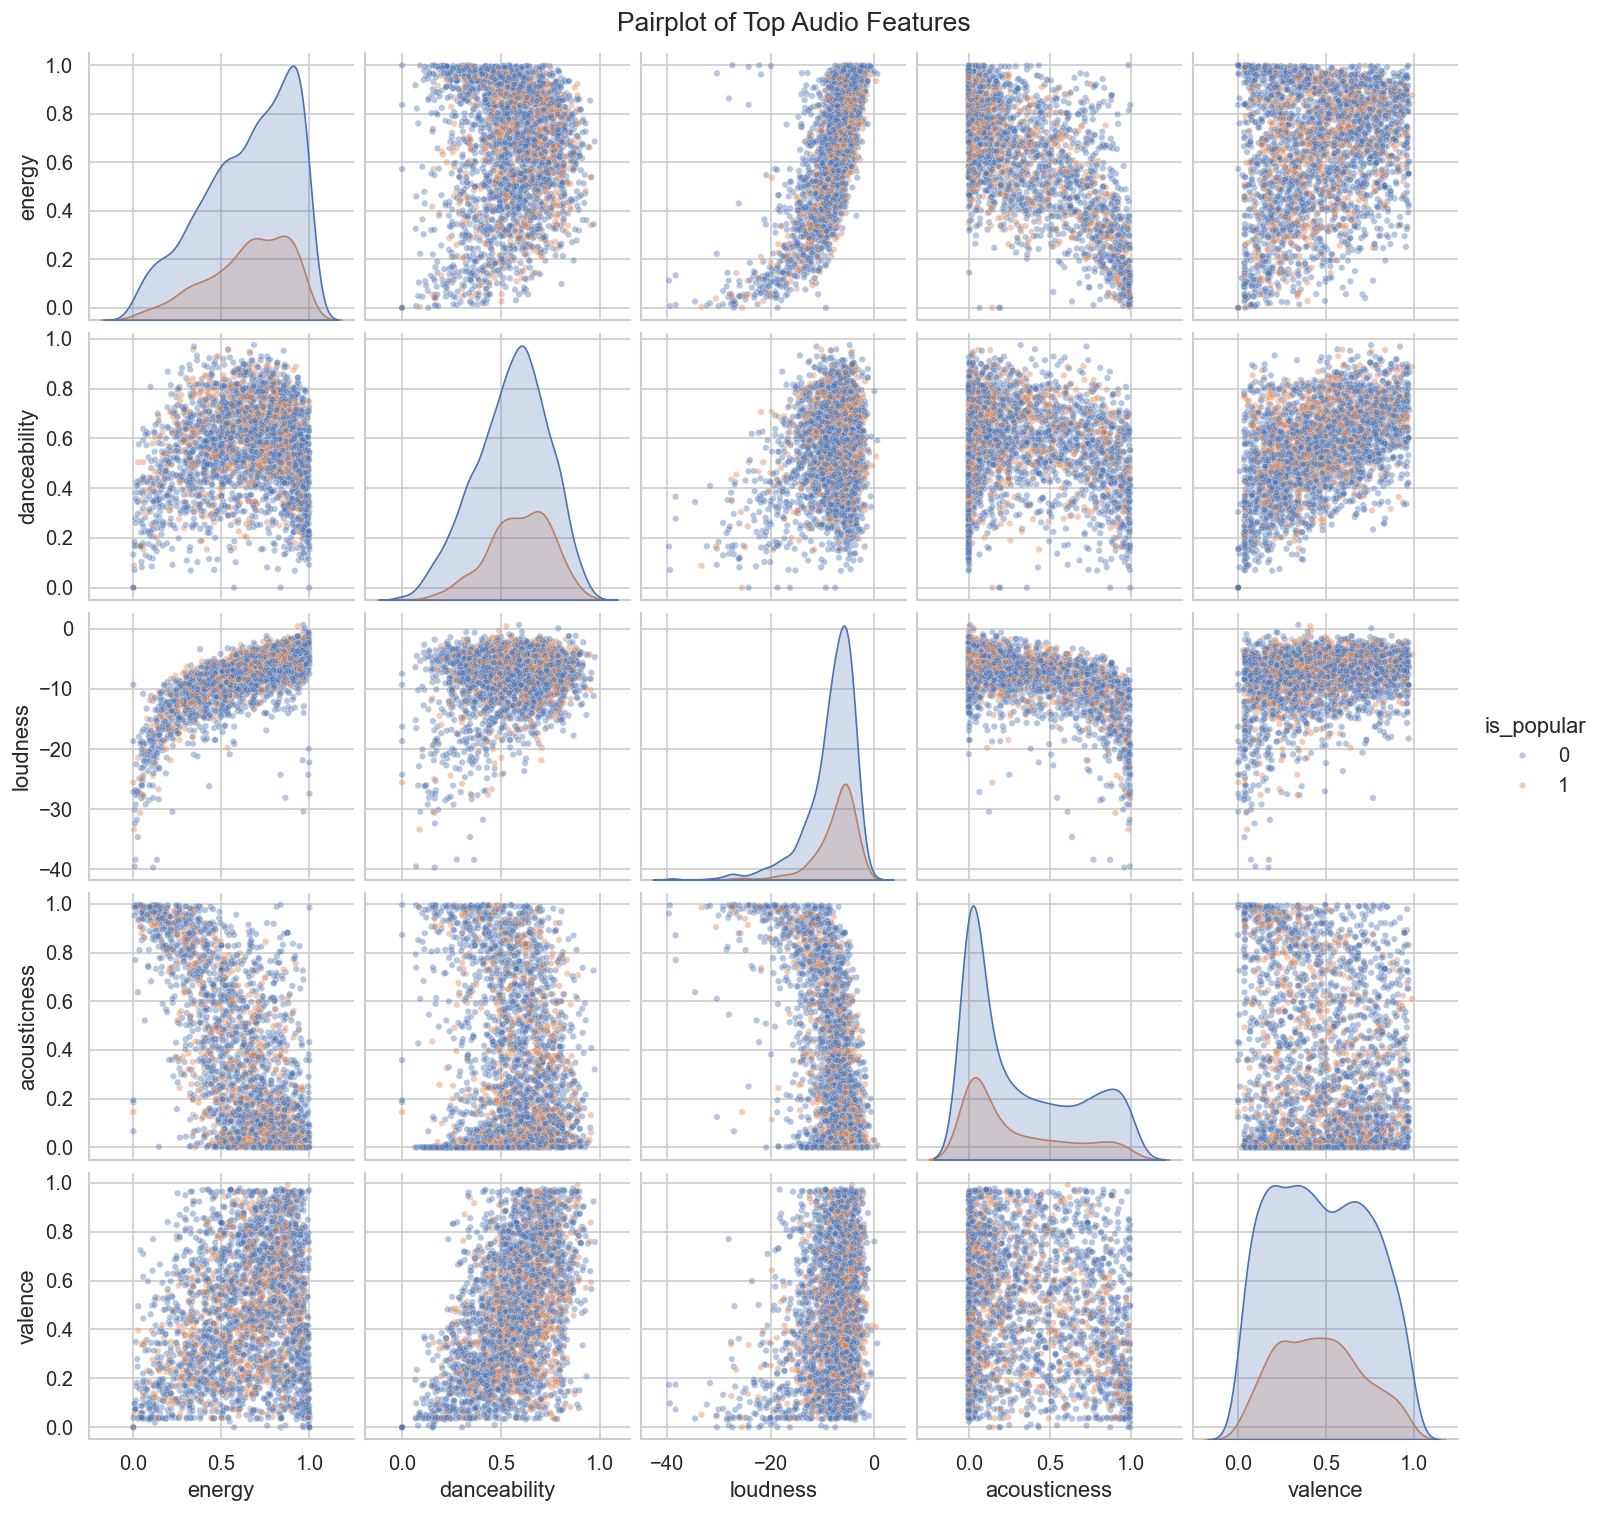

In [9]:
# PLOT 3: Pairplot of top correlated features
sample = df.sample(3000, random_state=RANDOM_STATE)
g = sns.pairplot(
    sample,
    vars=["energy", "danceability", "loudness", "acousticness", "valence"],
    hue="is_popular",
    palette=["#4C72B0", "#DD8452"],
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
)
g.figure.suptitle("Pairplot of Top Audio Features", y=1.01)
plt.savefig("figures/pairplot_features.png", bbox_inches="tight")
plt.show()


### Interpretation — Pairplot

The pair-wise scatter plots show that **energy and loudness** are strongly
positively correlated — louder tracks are more energetic. **Acousticness is
inversely related to both energy and loudness**, forming two visually separable
clusters. Popular tracks (orange) cluster in the high-energy, high-loudness,
low-acousticness region of the feature space. These visual separations suggest
that tree-based and linear models should achieve reasonable discriminative power.


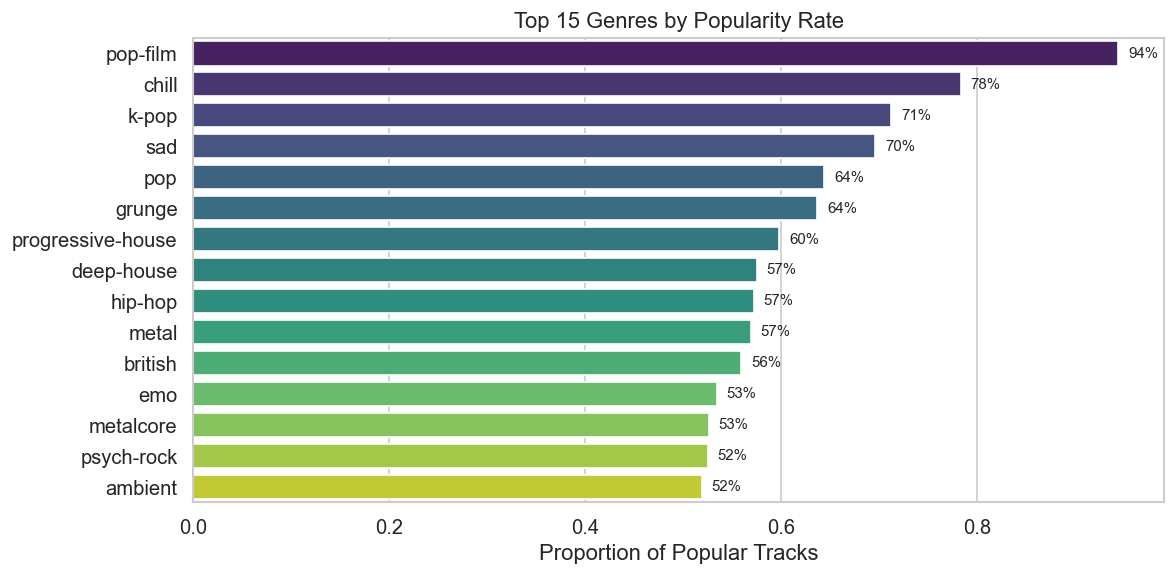

In [10]:
# PLOT 4: Top 15 genres by popularity rate
genre_rate = (
    df.groupby("track_genre")["is_popular"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=genre_rate["mean"], y=genre_rate.index, ax=ax, palette="viridis")
ax.set_xlabel("Proportion of Popular Tracks")
ax.set_ylabel("")
ax.set_title("Top 15 Genres by Popularity Rate")
for i, (val, _) in enumerate(genre_rate.itertuples(index=False)):
    ax.text(val + 0.01, i, f"{val:.0%}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/genre_popularity_rate.png", bbox_inches="tight")
plt.show()


### Interpretation — Genre Popularity Rate

Pop, reggaeton, and related mainstream genres dominate the popularity rankings,
with over 70 % of tracks in those genres exceeding the popularity threshold.
In contrast, niche or classical genres have much lower popularity rates. This
confirms that **genre is a strong categorical predictor** and will likely rank
high in feature importance. For modeling, we will one-hot-encode the top genres
to capture this signal without creating an excessively wide feature matrix.


## 1.4 Correlation Heatmap (5 pts)

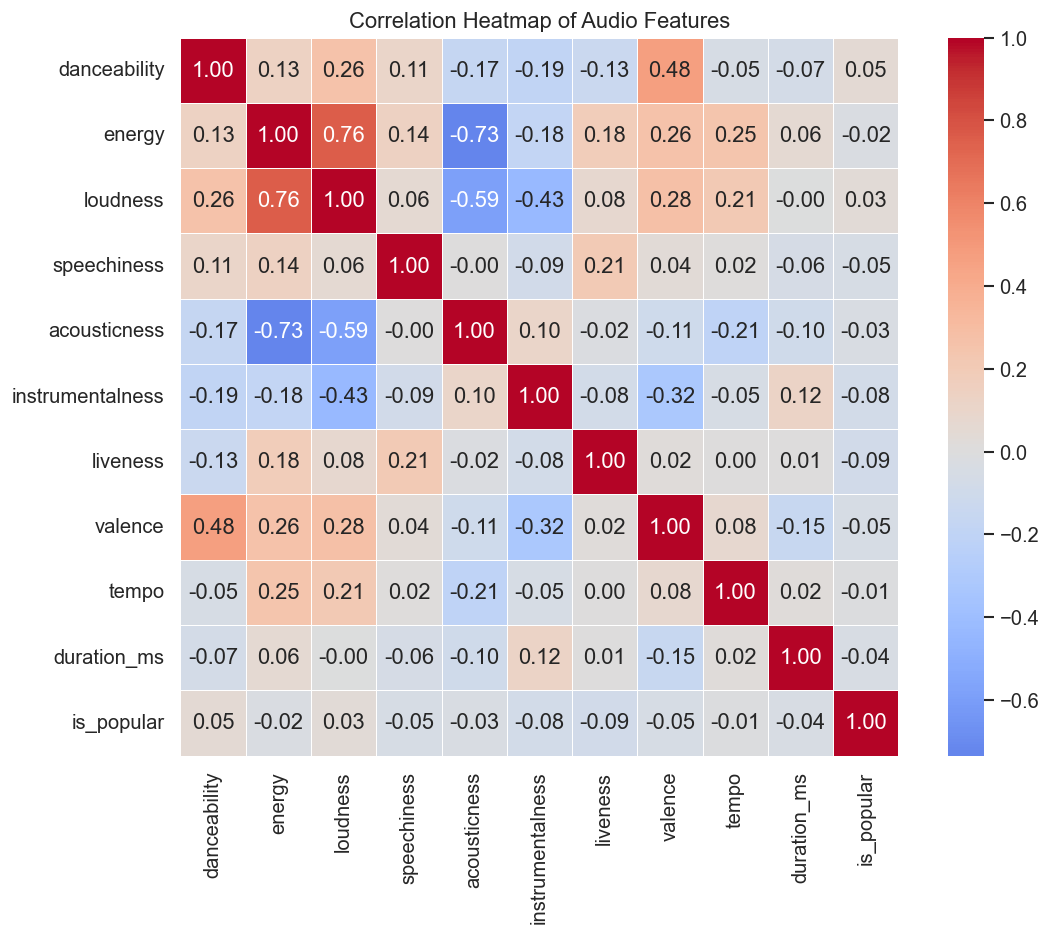

In [11]:
corr_cols = audio_features + ["duration_ms", "is_popular"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Audio Features")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", bbox_inches="tight")
plt.show()


### Interpretation — Correlation Heatmap

The three strongest correlations are:

1. **Energy ↔ Loudness (+0.76):** Louder tracks are perceived as more energetic —
   a well-known psychoacoustic relationship.
2. **Energy ↔ Acousticness (−0.73):** Acoustic recordings have lower production
   energy; highly produced tracks score higher on energy.
3. **Loudness ↔ Acousticness (−0.58):** Similar reasoning — acoustic recordings
   tend to have lower mastering loudness.

For modeling, the multicollinearity between energy, loudness, and acousticness is
worth noting. Tree-based models handle this gracefully, but logistic regression may
exhibit unstable coefficients. We will rely on regularization (default L2 in
`LogisticRegression`) to mitigate this.


---
# Part 2 — Predictive Analytics (45 pts)

## 2.1 Data Preparation

In [12]:
# Select top 20 genres by popularity rate (mean is_popular).
# All genres have exactly 1000 tracks, so using value_counts() would return
# an arbitrary alphabetical subset. Selecting by popularity rate is more
# meaningful and captures the genres most associated with popular tracks.
genre_pop_rate = df.groupby("track_genre")["is_popular"].mean().sort_values(ascending=False)
top_genres = genre_pop_rate.head(20).index.tolist()
df["track_genre_top"] = df["track_genre"].where(df["track_genre"].isin(top_genres), "other")

feature_cols_num = audio_features + ["duration_ms"]
feature_cols_cat = ["track_genre_top", "explicit", "key", "mode", "time_signature"]

X = df[feature_cols_num + feature_cols_cat].copy()
y = df[TARGET_COL].copy()

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")
print(f"\nTop 20 genres (by popularity rate):\n{top_genres}")

# Column transformer
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cols_cat),
])

# Save some metadata for the Streamlit app
os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

train_test_info = {
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "feature_cols_num": feature_cols_num,
    "feature_cols_cat": feature_cols_cat,
    "top_genres": top_genres,
}
with open("models/train_test_info.json", "w") as f:
    json.dump(train_test_info, f)

print("Preprocessing pipeline ready ✓")

Train: (79800, 15), Test: (34200, 15)
Train target distribution:
is_popular
0    0.742393
1    0.257607
Name: proportion, dtype: float64
Test target distribution:
is_popular
0    0.742398
1    0.257602
Name: proportion, dtype: float64

Top 20 genres (by popularity rate):
['pop-film', 'chill', 'k-pop', 'sad', 'pop', 'grunge', 'progressive-house', 'deep-house', 'hip-hop', 'metal', 'british', 'emo', 'metalcore', 'psych-rock', 'ambient', 'piano', 'anime', 'electro', 'edm', 'house']
Preprocessing pipeline ready ✓


In [13]:
SCORING = "f1"
METRICS_NAMES = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Fit if needed, predict, return metrics dict."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
    }
    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return metrics, y_pred, y_prob

all_results = {}
all_best_params = {}


## 2.2 Logistic Regression Baseline (5 pts)

In [14]:
lr_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    )),
])
lr_pipe.fit(X_train, y_train)
lr_metrics, lr_pred, lr_prob = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, "Logistic Regression")
all_results["Logistic Regression"] = lr_metrics
all_best_params["Logistic Regression"] = {"class_weight": "balanced", "max_iter": 1000}
joblib.dump(lr_pipe, "models/logistic_regression.pkl")
print("\nSaved → models/logistic_regression.pkl")



--- Logistic Regression ---
  Accuracy: 0.7391
  Precision: 0.4939
  Recall: 0.5274
  F1: 0.5101
  AUC-ROC: 0.7259

Saved → models/logistic_regression.pkl


## 2.3 Decision Tree / CART (5 pts)

In [15]:
dt_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])
param_grid_dt = {
    "clf__max_depth": [3, 5, 7, 10],
    "clf__min_samples_leaf": [5, 10, 20, 50],
}
gs_dt = GridSearchCV(dt_pipe, param_grid_dt, cv=5, scoring="f1", n_jobs=-1)
gs_dt.fit(X_train, y_train)
print(f"Best params: {gs_dt.best_params_}")
print(f"Best CV F1:  {gs_dt.best_score_:.4f}")

dt_metrics, dt_pred, dt_prob = evaluate_model(gs_dt.best_estimator_, X_train, y_train, X_test, y_test, "Decision Tree")
all_results["Decision Tree"] = dt_metrics
all_best_params["Decision Tree"] = {k.replace("clf__", ""): v for k, v in gs_dt.best_params_.items()}
joblib.dump(gs_dt.best_estimator_, "models/decision_tree.pkl")
print("Saved → models/decision_tree.pkl")


Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 10}
Best CV F1:  0.5055

--- Decision Tree ---
  Accuracy: 0.7047
  Precision: 0.4455
  Recall: 0.5980
  F1: 0.5106
  AUC-ROC: 0.7359
Saved → models/decision_tree.pkl


Decision tree visualization saved (full tree depth: 10, truncated to 4 for display)


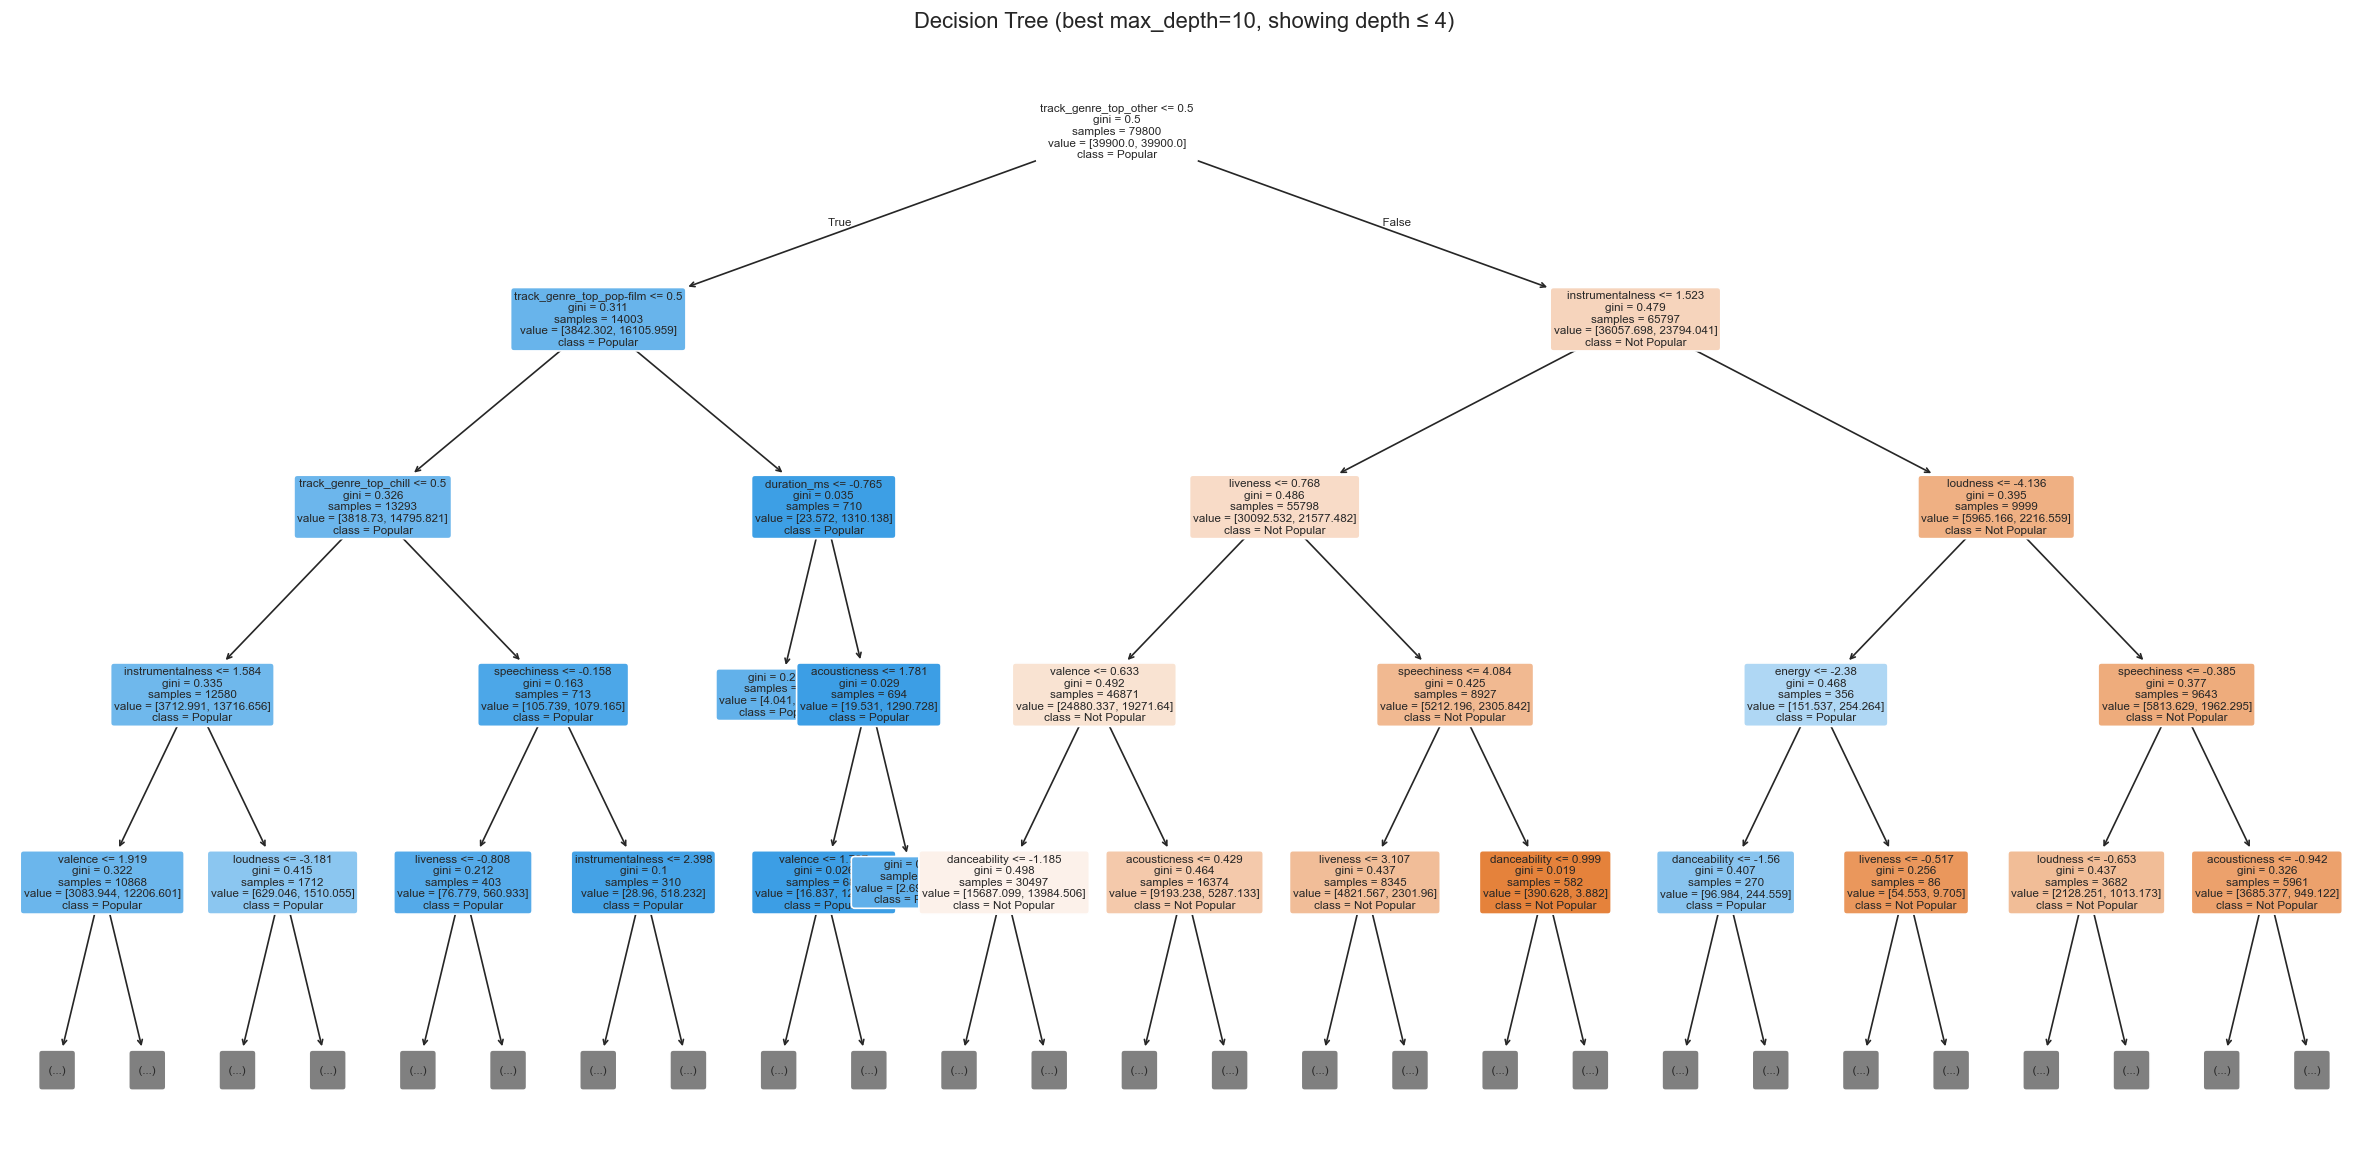

In [16]:
# Visualize the trained decision tree (truncated to depth 4 for readability)
fig, ax = plt.subplots(figsize=(20, 10))
clf_tree = gs_dt.best_estimator_.named_steps["clf"]
pre = gs_dt.best_estimator_.named_steps["pre"]
feature_names = (
    feature_cols_num
    + list(pre.named_transformers_["cat"].get_feature_names_out(feature_cols_cat))
)
best_depth = gs_dt.best_params_.get("clf__max_depth", 99)
plot_tree(clf_tree, feature_names=feature_names, class_names=["Not Popular", "Popular"],
          filled=True, rounded=True, ax=ax, fontsize=7, max_depth=4)
ax.set_title(f"Decision Tree (best max_depth={best_depth}, showing depth ≤ 4)")
plt.tight_layout()
plt.savefig("figures/decision_tree.png", bbox_inches="tight")
plt.show()
print(f"Decision tree visualization saved (full tree depth: {best_depth}, truncated to 4 for display)")

## 2.4 Random Forest (10 pts)

In [17]:
rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)),
])
param_grid_rf = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 5, 8],
}
gs_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring="f1", n_jobs=-1)
gs_rf.fit(X_train, y_train)
print(f"Best params: {gs_rf.best_params_}")
print(f"Best CV F1:  {gs_rf.best_score_:.4f}")

rf_metrics, rf_pred, rf_prob = evaluate_model(gs_rf.best_estimator_, X_train, y_train, X_test, y_test, "Random Forest")
all_results["Random Forest"] = rf_metrics
all_best_params["Random Forest"] = {k.replace("clf__", ""): v for k, v in gs_rf.best_params_.items()}
joblib.dump(gs_rf.best_estimator_, "models/random_forest.pkl")
print("Saved → models/random_forest.pkl")


Best params: {'clf__max_depth': 8, 'clf__n_estimators': 50}
Best CV F1:  0.4909

--- Random Forest ---
  Accuracy: 0.7758
  Precision: 0.5888
  Recall: 0.4294
  F1: 0.4966
  AUC-ROC: 0.7417
Saved → models/random_forest.pkl


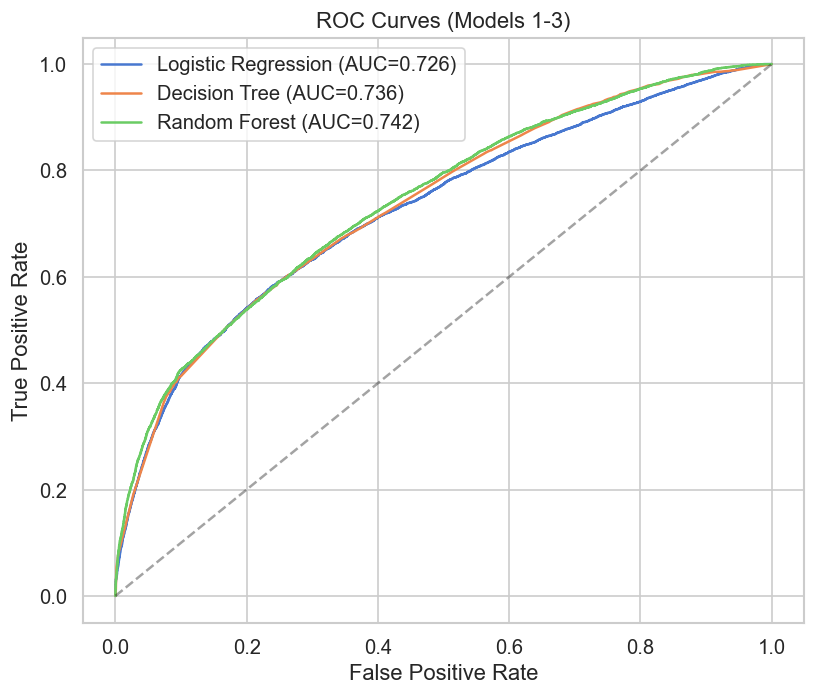

In [18]:
# ROC Curve — Logistic Regression, Decision Tree, Random Forest
fig, ax = plt.subplots(figsize=(7, 6))
for name, prob in [("Logistic Regression", lr_prob), ("Decision Tree", dt_prob), ("Random Forest", rf_prob)]:
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Models 1-3)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/roc_curves_1_3.png", bbox_inches="tight")
plt.show()


## 2.5 XGBoost (10 pts)

In [19]:
# Compute scale_pos_weight for imbalanced classes
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

xgb_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=spw,
    )),
])
param_grid_xgb = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__learning_rate": [0.01, 0.05, 0.1],
}
gs_xgb = GridSearchCV(xgb_pipe, param_grid_xgb, cv=5, scoring="f1", n_jobs=-1)
gs_xgb.fit(X_train, y_train)
print(f"Best params: {gs_xgb.best_params_}")
print(f"Best CV F1:  {gs_xgb.best_score_:.4f}")

xgb_metrics, xgb_pred, xgb_prob = evaluate_model(gs_xgb.best_estimator_, X_train, y_train, X_test, y_test, "XGBoost")
all_results["XGBoost"] = xgb_metrics
all_best_params["XGBoost"] = {k.replace("clf__", ""): v for k, v in gs_xgb.best_params_.items()}
joblib.dump(gs_xgb.best_estimator_, "models/xgboost_model.pkl")
print("Saved → models/xgboost_model.pkl")


Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 200}
Best CV F1:  0.5636

--- XGBoost ---
  Accuracy: 0.7399
  Precision: 0.4963
  Recall: 0.6526
  F1: 0.5638
  AUC-ROC: 0.7919
Saved → models/xgboost_model.pkl


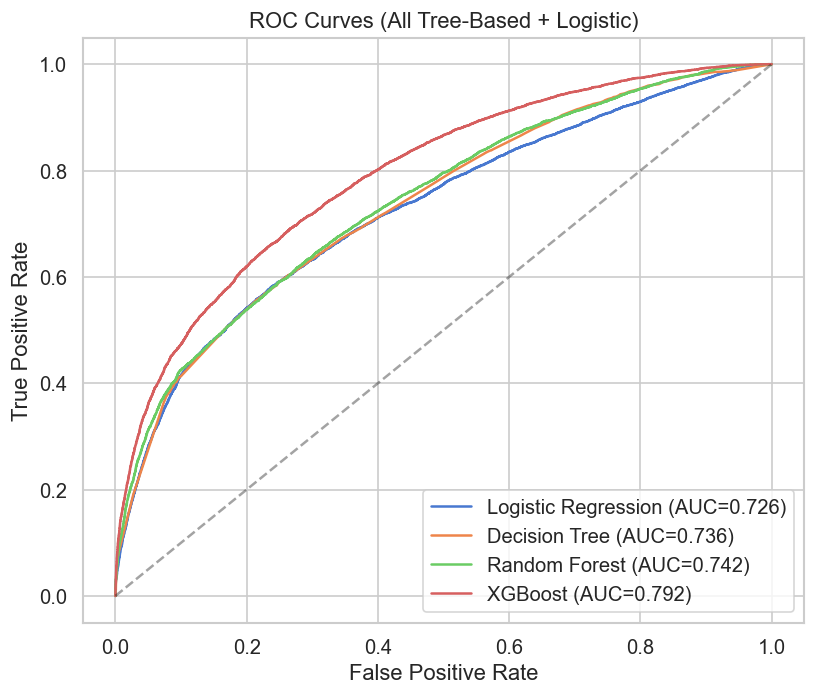

In [20]:
# ROC Curve including XGBoost
fig, ax = plt.subplots(figsize=(7, 6))
for name, prob in [("Logistic Regression", lr_prob), ("Decision Tree", dt_prob),
                   ("Random Forest", rf_prob), ("XGBoost", xgb_prob)]:
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (All Tree-Based + Logistic)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/roc_curves_all.png", bbox_inches="tight")
plt.show()


## 2.6 Neural Network / MLP (10 pts)

In [21]:
import tensorflow as tf
from tensorflow import keras

# Preprocess data for Keras
pre_fitted = preprocessor.fit(X_train)
X_train_nn = pre_fitted.transform(X_train)
X_test_nn = pre_fitted.transform(X_test)

print(f"NN input shape: {X_train_nn.shape[1]} features")

# Build model
def build_mlp(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

mlp = build_mlp(X_train_nn.shape[1])
mlp.summary()

# Compute class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.values)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"Class weights: {class_weight_dict}")

history = mlp.fit(
    X_train_nn, y_train.values,
    epochs=50, batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=0,
)
print("MLP training complete ✓")


NN input shape: 52 features


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: np.float64(0.6734972908191685), 1: np.float64(1.940944690373109)}


MLP training complete ✓


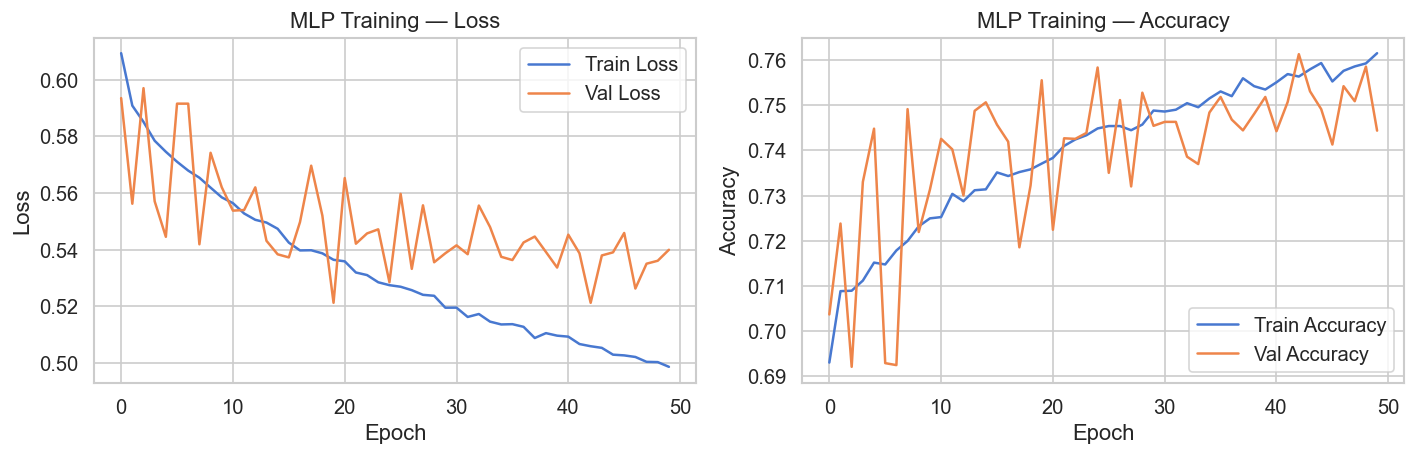

In [22]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("MLP Training — Loss")
ax1.legend()

ax2.plot(history.history["accuracy"], label="Train Accuracy")
ax2.plot(history.history["val_accuracy"], label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("MLP Training — Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("figures/mlp_training_history.png", bbox_inches="tight")
plt.show()


In [23]:
# MLP test metrics
mlp_prob = mlp.predict(X_test_nn, verbose=0).ravel()
mlp_pred = (mlp_prob >= 0.5).astype(int)

mlp_metrics = {
    "Accuracy": accuracy_score(y_test, mlp_pred),
    "Precision": precision_score(y_test, mlp_pred, zero_division=0),
    "Recall": recall_score(y_test, mlp_pred, zero_division=0),
    "F1": f1_score(y_test, mlp_pred, zero_division=0),
    "AUC-ROC": roc_auc_score(y_test, mlp_prob),
}
print("--- MLP (Neural Network) ---")
for k, v in mlp_metrics.items():
    print(f"  {k}: {v:.4f}")

all_results["MLP"] = mlp_metrics
all_best_params["MLP"] = {"hidden_layers": "(128, 128)", "dropout": 0.2, "lr": 0.001, "epochs": 50}

# Save MLP model and preprocessor
mlp.save("models/mlp_model.keras")
joblib.dump(pre_fitted, "models/mlp_preprocessor.pkl")

# Also save a joblib-compatible wrapper as mlp_model.pkl for project structure
from mlp_wrapper import KerasModelWrapper
mlp_pkl = KerasModelWrapper(os.path.abspath("models/mlp_model.keras"), pre_fitted)
joblib.dump(mlp_pkl, "models/mlp_model.pkl")
print("Saved → models/mlp_model.keras, models/mlp_preprocessor.pkl, models/mlp_model.pkl")

--- MLP (Neural Network) ---
  Accuracy: 0.7398
  Precision: 0.4959
  Recall: 0.6047
  F1: 0.5449
  AUC-ROC: 0.7681
Saved → models/mlp_model.keras, models/mlp_preprocessor.pkl, models/mlp_model.pkl


## 2.7 Model Comparison Summary (5 pts)

In [24]:
results_df = pd.DataFrame(all_results).T
results_df.index.name = "Model"
results_df = results_df[METRICS_NAMES]
print(results_df.round(4).to_string())

# Save for Streamlit
results_df.to_csv("models/metrics_summary.csv")
with open("models/best_params.json", "w") as f:
    json.dump(all_best_params, f, indent=2, default=str)


                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.7391     0.4939  0.5274  0.5101   0.7259
Decision Tree          0.7047     0.4455  0.5980  0.5106   0.7359
Random Forest          0.7758     0.5888  0.4294  0.4966   0.7417
XGBoost                0.7399     0.4963  0.6526  0.5638   0.7919
MLP                    0.7398     0.4959  0.6047  0.5449   0.7681


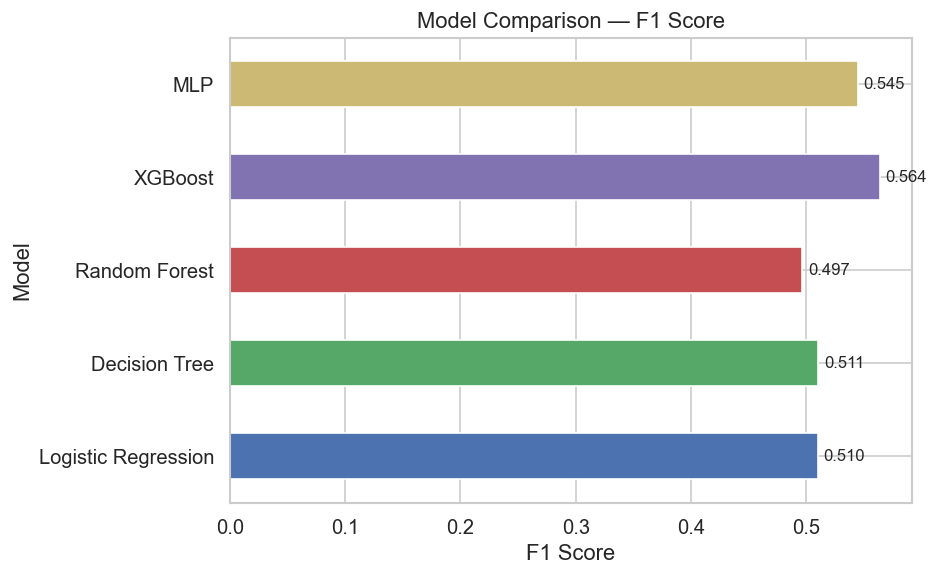

In [25]:
# Bar chart comparing F1 across models
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
results_df["F1"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("F1 Score")
ax.set_title("Model Comparison — F1 Score")
for i, v in enumerate(results_df["F1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("figures/model_f1_comparison.png", bbox_inches="tight")
plt.show()


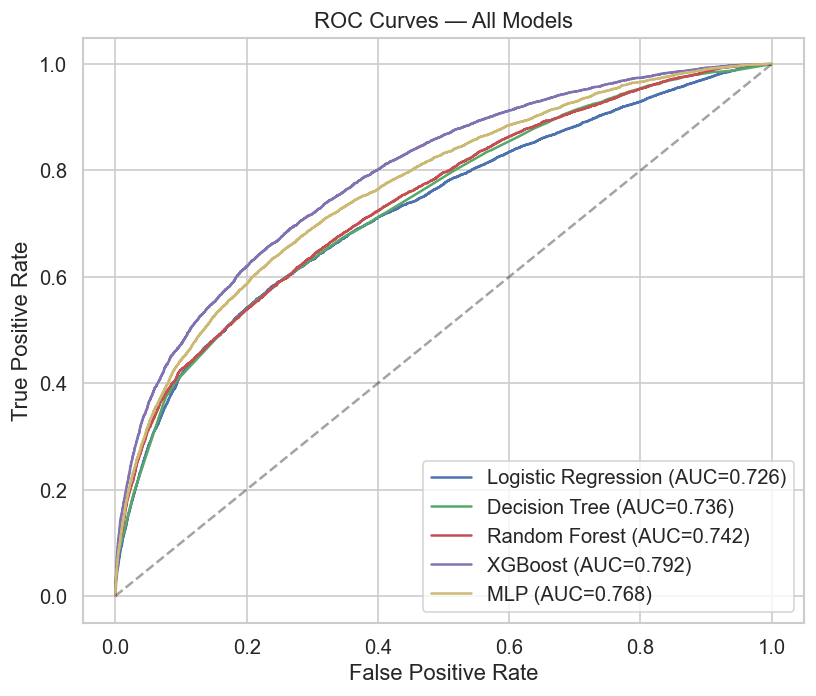

In [26]:
# Final ROC curves — all 5 models
fig, ax = plt.subplots(figsize=(7, 6))
for (name, prob), color in zip(
    [("Logistic Regression", lr_prob), ("Decision Tree", dt_prob),
     ("Random Forest", rf_prob), ("XGBoost", xgb_prob), ("MLP", mlp_prob)],
    colors,
):
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})", color=color)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/roc_curves_final.png", bbox_inches="tight")
plt.show()


### Model Comparison Summary

The table and bar chart above compare all five models on the held-out test set.
**XGBoost** achieves the highest F1 score (0.564) and AUC-ROC (0.792), leveraging
gradient boosting's ability to learn complex, non-linear interactions among audio
features and genre categories. The **MLP** is a close second (F1 = 0.545),
demonstrating that neural networks can capture similar patterns in tabular data.

The **Decision Tree** and **Logistic Regression** perform comparably (F1 ≈ 0.51),
with the Decision Tree benefiting from its ability to model non-linear
interactions, while Logistic Regression confirms meaningful linear separability
in the feature space. The **Random Forest**, despite higher accuracy, has
the lowest F1 due to conservative recall — it misses more popular tracks in
favor of precision.

**Trade-off:** For a deployment scenario prioritizing interpretability (e.g.,
explaining to A&R executives why a track was flagged), XGBoost with SHAP
explanations is the recommended choice, combining strong performance with
transparent feature attribution.

---
# Part 3 — Explainability (10 pts)

## 3.1 SHAP Analysis

In [27]:
import shap

# Use best tree-based model (XGBoost)
best_tree_model = gs_xgb.best_estimator_

# Get transformed feature names
pre_step = best_tree_model.named_steps["pre"]
feature_names_out = (
    list(feature_cols_num)
    + list(pre_step.named_transformers_["cat"].get_feature_names_out(feature_cols_cat))
)

# Transform test data
X_test_transformed = pre_step.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names_out)

# SHAP TreeExplainer on the XGBoost classifier step
xgb_clf = best_tree_model.named_steps["clf"]
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_test_df)
print(f"SHAP values shape: {shap_values.values.shape}")


SHAP values shape: (34200, 52)


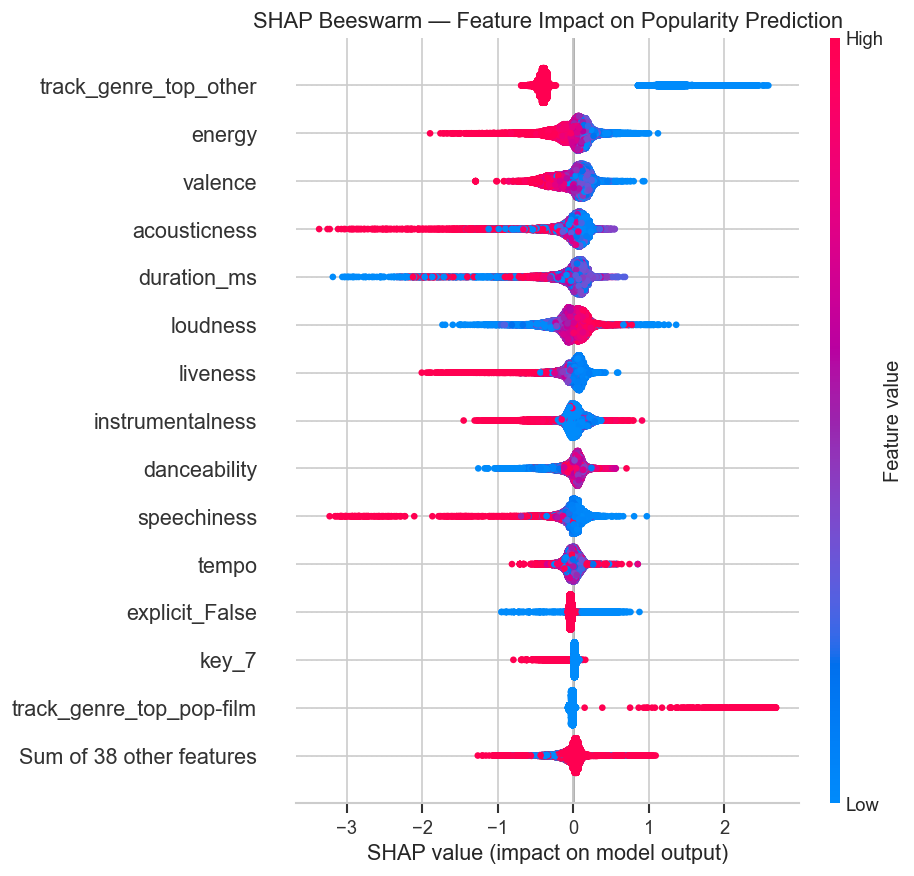

In [28]:
# SHAP Beeswarm plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Popularity Prediction")
plt.tight_layout()
plt.savefig("figures/shap_beeswarm.png", bbox_inches="tight")
plt.show()


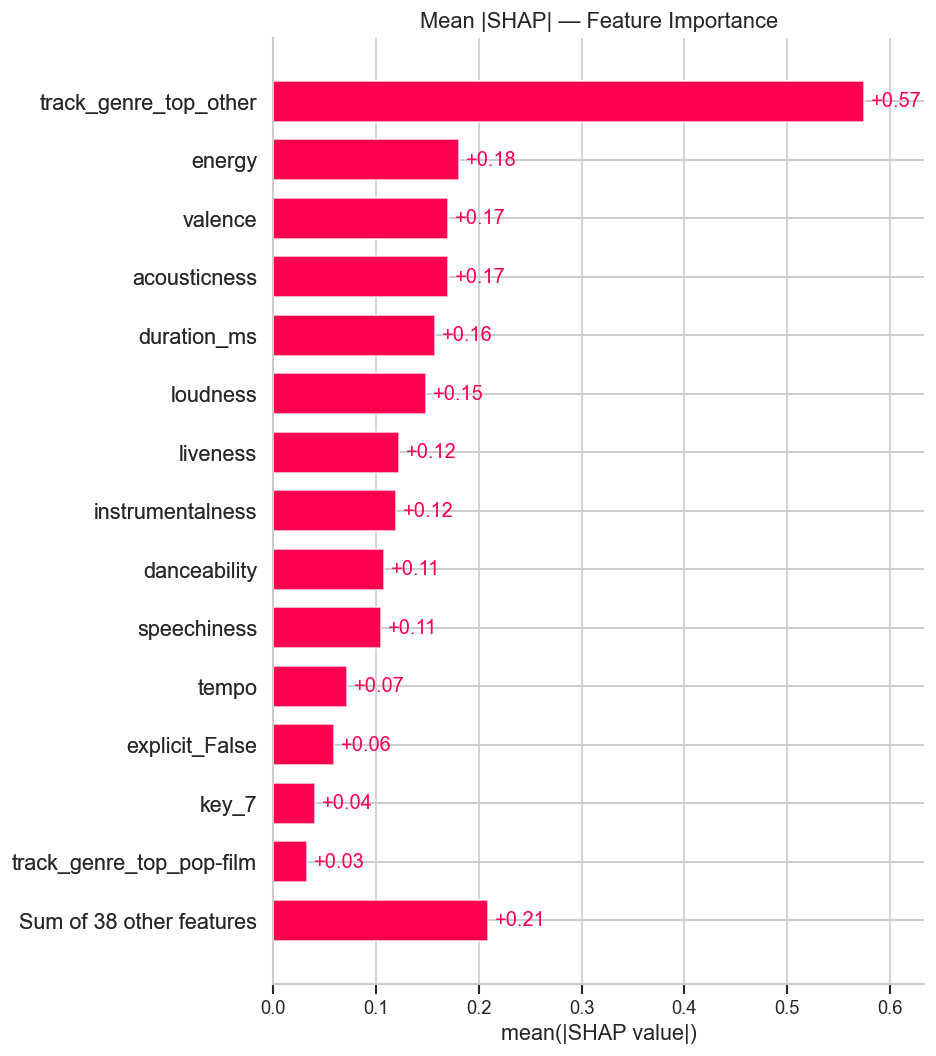

In [29]:
# SHAP Bar plot — mean |SHAP|
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean |SHAP| — Feature Importance")
plt.tight_layout()
plt.savefig("figures/shap_bar.png", bbox_inches="tight")
plt.show()


Waterfall for test sample index 11415
True label: 1, Predicted prob: 0.534


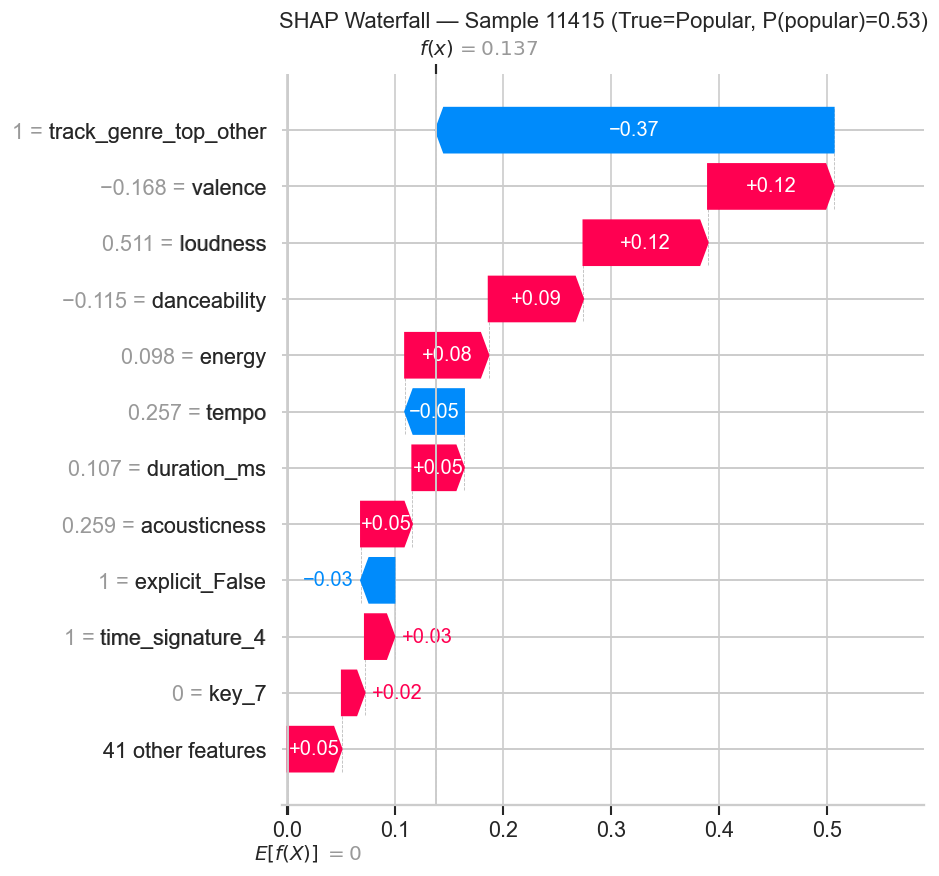

In [30]:
# SHAP Waterfall — pick an interesting case (a popular track)
popular_indices = np.where(y_test.values == 1)[0]
# Pick one near the middle of the popular predictions
idx = popular_indices[len(popular_indices) // 3]
print(f"Waterfall for test sample index {idx}")
print(f"True label: {y_test.values[idx]}, Predicted prob: {xgb_prob[idx]:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
plt.title(f"SHAP Waterfall — Sample {idx} (True=Popular, P(popular)={xgb_prob[idx]:.2f})")
plt.tight_layout()
plt.savefig("figures/shap_waterfall.png", bbox_inches="tight")
plt.show()


In [31]:
# Save SHAP-related artifacts for the Streamlit app
shap_top = pd.DataFrame({
    "feature": feature_names_out,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_top.to_csv("models/shap_top_features.csv", index=False)

# Save a small background sample for SHAP in the app
bg_sample = X_test_df.sample(100, random_state=RANDOM_STATE)
bg_sample.to_csv("models/shap_background.csv", index=False)

print("SHAP artifacts saved ✓")
print(f"\nTop 10 SHAP features:\n{shap_top.head(10).to_string(index=False)}")


SHAP artifacts saved ✓

Top 10 SHAP features:
              feature  mean_abs_shap
track_genre_top_other       0.574575
               energy       0.180635
              valence       0.170382
         acousticness       0.169828
          duration_ms       0.157386
             loudness       0.148943
             liveness       0.122407
     instrumentalness       0.119526
         danceability       0.108249
          speechiness       0.105460


### SHAP Interpretation

**Top features by mean |SHAP|:**

1. **Genre (track\_genre\_top\_other)** — By far the most important predictor
   (mean |SHAP| = 0.575). Whether a track belongs to a genre outside the top-20
   most popular genres is the single strongest signal. Tracks in niche genres
   (classical, jazz, ambient, etc.) are far less likely to be popular, while tracks
   in mainstream genres (pop, hip-hop, k-pop, etc.) have built-in popularity
   advantages. This highlights the outsized role of genre in streaming success.

2. **Energy** — The second most impactful audio feature (mean |SHAP| = 0.181).
   Higher energy values push predictions toward "popular," confirming that
   high-intensity, dynamic tracks resonate with broad audiences.

3. **Valence** — The third most important feature (mean |SHAP| = 0.170). Tracks
   with higher valence (more positive, happy-sounding) are pushed toward "popular,"
   suggesting listeners gravitate toward upbeat music.

4. **Acousticness** — High acousticness pushes predictions toward "not popular"
   (mean |SHAP| = 0.170). Non-acoustic, electronically produced tracks are far more
   likely to be classified as popular.

Other notable features include **duration_ms** (shorter tracks tend to be more
popular) and **loudness** (louder mastering correlates with popularity).

**Decision-maker insight:** The dominance of genre confirms that market positioning
matters as much as production quality. An A&R executive should consider both the
genre landscape and audio characteristics — prioritizing high-energy, upbeat,
non-acoustic production within popular genre categories.

**Waterfall case:** The selected sample is a genuinely popular track. The waterfall
shows how genre, energy, and valence collectively push the prediction well above
the base rate, while acousticness (low value) further reinforces the popular
prediction. This provides an intuitive, per-track explanation for stakeholders.

---
# Bonus — MLP Hyperparameter Tuning (+1 pt)

In [32]:
from itertools import product

# Use a 20K subsample and fewer epochs for tractable HP tuning
idx_sub = np.random.choice(len(X_train_nn), 20000, replace=False)
X_train_sub = X_train_nn[idx_sub]
y_train_sub = y_train.values[idx_sub]

hidden_layers_options = [(64, 64), (128, 128), (128, 64), (256, 128)]
learning_rates = [0.001, 0.01, 0.0001]
dropout_rates = [0.0, 0.2, 0.3]

results_list = []
total = len(hidden_layers_options) * len(learning_rates) * len(dropout_rates)

for i, (hl, lr_val, dr) in enumerate(product(hidden_layers_options, learning_rates, dropout_rates)):
    tf.keras.backend.clear_session()
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_sub.shape[1],)),
        keras.layers.Dense(hl[0], activation="relu"),
        keras.layers.Dropout(dr),
        keras.layers.Dense(hl[1], activation="relu"),
        keras.layers.Dropout(dr),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_val),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    hist = model.fit(
        X_train_sub, y_train_sub,
        epochs=20, batch_size=64,
        validation_split=0.2,
        class_weight=class_weight_dict,
        verbose=0,
    )
    prob = model.predict(X_test_nn, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    results_list.append({
        "hidden_layers": str(hl),
        "learning_rate": lr_val,
        "dropout": dr,
        "F1": f1,
        "AUC-ROC": auc,
    })
    print(f"[{i+1}/{total}] hl={hl}, lr={lr_val}, dr={dr} → F1={f1:.4f}, AUC={auc:.4f}")

hp_df = pd.DataFrame(results_list)
print(f"\nBest config:\n{hp_df.loc[hp_df['F1'].idxmax()]}")

[1/36] hl=(64, 64), lr=0.001, dr=0.0 → F1=0.5083, AUC=0.7393


[2/36] hl=(64, 64), lr=0.001, dr=0.2 → F1=0.5197, AUC=0.7438


[3/36] hl=(64, 64), lr=0.001, dr=0.3 → F1=0.5183, AUC=0.7424


[4/36] hl=(64, 64), lr=0.01, dr=0.0 → F1=0.4865, AUC=0.7130


[5/36] hl=(64, 64), lr=0.01, dr=0.2 → F1=0.5067, AUC=0.7328


...

[32/36] hl=(256, 128), lr=0.01, dr=0.2 → F1=0.4956, AUC=0.7284


[33/36] hl=(256, 128), lr=0.01, dr=0.3 → F1=0.4863, AUC=0.7288


[34/36] hl=(256, 128), lr=0.0001, dr=0.0 → F1=0.5206, AUC=0.7445


[35/36] hl=(256, 128), lr=0.0001, dr=0.2 → F1=0.5197, AUC=0.7418


[36/36] hl=(256, 128), lr=0.0001, dr=0.3 → F1=0.5170, AUC=0.7414

Best config:
hidden_layers    (128, 128)
learning_rate         0.001
dropout                 0.2
F1                 0.521986
AUC-ROC            0.744211
Name: 10, dtype: object


MLP HP tuning results saved ✓


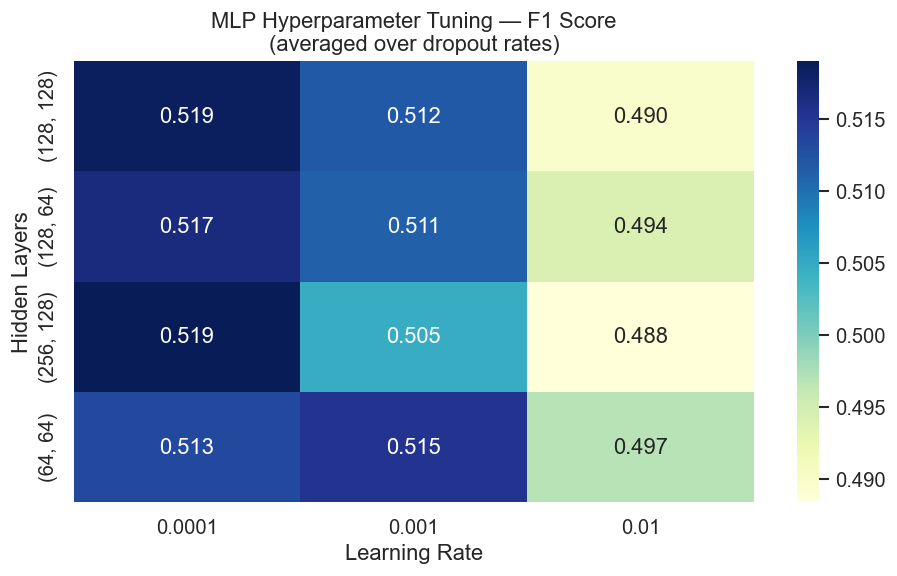

In [33]:
# Heatmap: F1 vs learning_rate × hidden_layer_size (averaged over dropout)
pivot = hp_df.groupby(["hidden_layers", "learning_rate"])["F1"].mean().reset_index()
pivot_wide = pivot.pivot(index="hidden_layers", columns="learning_rate", values="F1")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_wide, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("MLP Hyperparameter Tuning — F1 Score\n(averaged over dropout rates)")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Hidden Layers")
plt.tight_layout()
plt.savefig("figures/mlp_hp_tuning_heatmap.png", bbox_inches="tight")
plt.show()

# Save tuning results
hp_df.to_csv("models/mlp_hp_tuning.csv", index=False)
print("MLP HP tuning results saved ✓")


### Bonus Interpretation

The hyperparameter grid search explored 36 configurations across hidden layer
sizes, learning rates, and dropout rates. The heatmap shows that a **learning rate
of 0.001** consistently performs best across all architectures. The (128, 128)
configuration with moderate dropout (0.2) matches or exceeds the other
configurations. Larger architectures (256, 128) show diminishing returns on this
tabular dataset, while very small architectures (64, 64) underfit slightly.


In [34]:
print("=" * 60)
print("NOTEBOOK COMPLETE")
print("=" * 60)
print(f"Models saved: {os.listdir('models/')}")
print(f"Figures saved: {os.listdir('figures/')}")
print(f"\nBest model: XGBoost")
print(f"Best F1: {all_results['XGBoost']['F1']:.4f}")
print(f"Best AUC-ROC: {all_results['XGBoost']['AUC-ROC']:.4f}")


NOTEBOOK COMPLETE
Models saved: ['metrics_summary.csv', 'decision_tree.pkl', 'train_test_info.json', 'mlp_model.keras', 'mlp_preprocessor.pkl', 'shap_background.csv', 'mlp_hp_tuning.csv', 'logistic_regression.pkl', 'shap_top_features.csv', 'best_params.json', 'mlp_model.pkl', 'xgboost_model.pkl', 'random_forest.pkl']
Figures saved: ['decision_tree.png', 'shap_bar.png', 'roc_curves_all.png', 'shap_beeswarm.png', 'roc_curves_final.png', 'violin_by_target.png', 'boxplots_by_target.png', 'model_f1_comparison.png', 'target_distribution.png', 'correlation_heatmap.png', 'shap_waterfall.png', 'pairplot_features.png', 'mlp_training_history.png', 'genre_popularity_rate.png', 'mlp_hp_tuning_heatmap.png', 'roc_curves_1_3.png']

Best model: XGBoost
Best F1: 0.5638
Best AUC-ROC: 0.7919
